In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_mat = pd.read_csv("W:/MyProjects/FailSafe/data/raw/student-mat.csv",sep=';')
df_por = pd.read_csv("W:/MyProjects/FailSafe/data/raw/student-por.csv",sep=';')

df_mat["subject"] = "Math"
df_por["subject"] = "Portuguese"

df = pd.concat([df_mat,df_por], ignore_index=True)

print(f"Total students: {df.shape[0]}")
print(f"Total features: {df.shape[1]}")
print("\nMissing Values:\n", df.isnull().sum().max(), "missing values found.")

display(df.head(3))

Total students: 1044
Total features: 34

Missing Values:
 0 missing values found.


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,GP,"""F""",18,"""U""","""GT3""","""A""",4,4,"""at_home""","""teacher""",...,3,4,1,1,3,6,"""5""","""6""",6,Math
1,GP,"""F""",17,"""U""","""GT3""","""T""",1,1,"""at_home""","""other""",...,3,3,1,1,3,4,"""5""","""5""",6,Math
2,GP,"""F""",15,"""U""","""LE3""","""T""",1,1,"""at_home""","""other""",...,3,2,2,3,3,10,"""7""","""8""",10,Math


In [4]:
df.columns

Index(['school', ' sex', ' age', ' address', ' famsize', ' Pstatus', ' Medu',
       ' Fedu', ' Mjob      ', ' Fjob      ', ' reason      ', ' guardian',
       ' traveltime', ' studytime', ' failures', ' schoolsup', ' famsup',
       ' paid ', ' activities', ' nursery', ' higher', ' internet',
       ' romantic', ' famrel', ' freetime', ' goout', ' Dalc', ' Walc',
       ' health', ' absences', ' G1  ', ' G2  ', ' G3', 'subject'],
      dtype='str')

In [5]:
df.columns = df.columns.str.strip()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.replace('"', '').str.strip()

df['G1'] = pd.to_numeric(df['G1'])
df['G2'] = pd.to_numeric(df['G2'])

print("Cleaned Columns:\n", df.columns.tolist())
print("\nData Types for Grades:\n", df[['G1', 'G2', 'G3']].dtypes)

Cleaned Columns:
 ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'subject']

Data Types for Grades:
 G1    int64
G2    int64
G3    int64
dtype: object


C:\Users\anuro\AppData\Local\Temp\ipykernel_24876\3905962007.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


In [6]:
df.head(3)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,Math
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,Math
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,Math


C:\Users\anuro\AppData\Local\Temp\ipykernel_24876\1084746915.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="failures", y="failed", data=df, palette="viridis", ci=None)
C:\Users\anuro\AppData\Local\Temp\ipykernel_24876\1084746915.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="failures", y="failed", data=df, palette="viridis", ci=None)


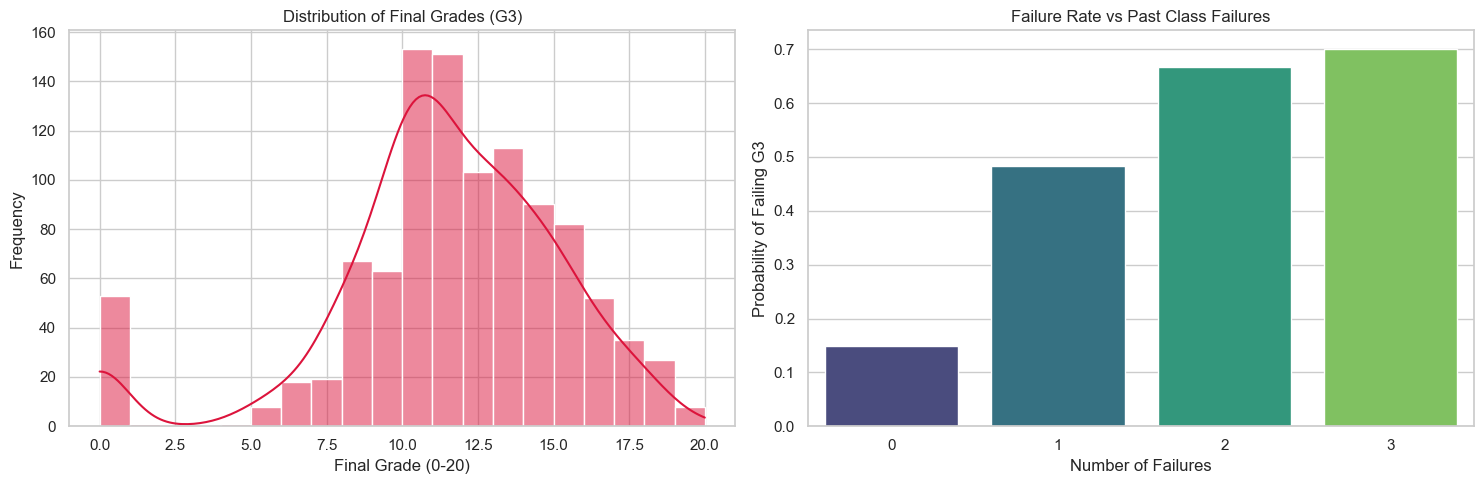

In [7]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['G3'], bins=20, kde=True, color='crimson')
plt.title('Distribution of Final Grades (G3)')
plt.xlabel('Final Grade (0-20)')
plt.ylabel('Frequency')


df["failed"] = df["G3"] < 10

plt.subplot(1, 2, 2)
sns.barplot(x="failures", y="failed", data=df, palette="viridis", ci=None)
plt.title('Failure Rate vs Past Class Failures')
plt.xlabel('Number of Failures')
plt.ylabel('Probability of Failing G3')

plt.tight_layout()
plt.show()

C:\Users\anuro\AppData\Local\Temp\ipykernel_24876\4241473955.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_target.index, y=corr_with_target.values, palette="coolwarm")


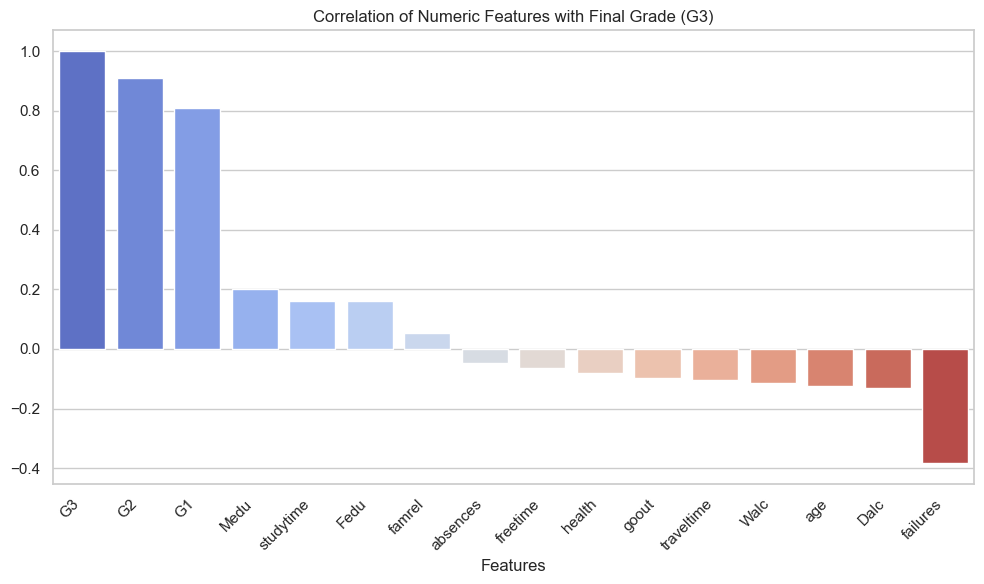


Top Predictors of Success:
 G3      1.000000
G2      0.910743
G1      0.809142
Medu    0.201472
Name: G3, dtype: float64

Top Predictors of Failure:
 Walc       -0.115740
age        -0.125282
Dalc       -0.129642
failures   -0.383145
Name: G3, dtype: float64


In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

corr_with_target = df[numeric_cols].corr()["G3"].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=corr_with_target.index, y=corr_with_target.values, palette="coolwarm")
plt.title('Correlation of Numeric Features with Final Grade (G3)')
plt.xlabel('Features') 
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


print("\nTop Predictors of Success:\n", corr_with_target.head(4))
print("\nTop Predictors of Failure:\n", corr_with_target.tail(4))

#### PRE-PROSESSING

In [9]:
df['risk'] = (df['G3']<10).astype(int)

df = df.drop(columns=['G3', 'failed'], errors='ignore')

X_early = df.drop(columns=['G1', 'G2', 'risk'])
y_early = df['risk']

X_mid = df.drop(columns=['G2', 'risk'])
y_mid = df['risk']

print("--- EARLY MODEL ---")
print(f"Features: {X_early.shape[1]}")
print(f"Columns: {X_early.columns.tolist()[:5]}...\n")

print("--- MID-SEMESTER MODEL ---")
print(f"Features: {X_mid.shape[1]}")
print(f"Columns: {X_mid.columns.tolist()[:5]}...\n")

# Checking Target Class Imbalance
print("--- TARGET DISTRIBUTION (Risk) ---")
print((y_early.value_counts(normalize=True) * 100).round(2).astype(str) + '%')

--- EARLY MODEL ---
Features: 31
Columns: ['school', 'sex', 'age', 'address', 'famsize']...

--- MID-SEMESTER MODEL ---
Features: 32
Columns: ['school', 'sex', 'age', 'address', 'famsize']...

--- TARGET DISTRIBUTION (Risk) ---
risk
0    77.97%
1    22.03%
Name: proportion, dtype: str


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

binary_cols = ['schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})     # Binary mapping of yes and no to 1 and 0

df['support_index'] = df['schoolsup'] + df['famsup'] + df['higher']
df['risk_behavior'] = df['Dalc'] + df['Walc'] + df['goout']
df['engagement'] = df['studytime'] - (df['absences'] / 10)          # Feature Engineering (Domain Knowledge)

df_encoded = pd.get_dummies(df, drop_first=True)    # One-hot encoding of categorical variables, dropping the first category to avoid multicollinearity

X = df_encoded.drop(columns=['G1', 'G2', 'risk'], errors='ignore')
y = df_encoded['risk']          # Define Features (X) and Target (y) for the EARLY MODEL

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67, stratify=y)

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print(f"Training Data Shape: {X_train_scaled.shape}")
print(f"Testing Data Shape: {X_test_scaled.shape}")
print(f"Train At-Risk %: {y_train.mean():.2%}")
print(f"Test At-Risk %: {y_test.mean():.2%}")

Training Data Shape: (835, 43)
Testing Data Shape: (209, 43)
Train At-Risk %: 22.04%
Test At-Risk %: 22.01%


In [12]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV

# Formula: Count of Negative Class (Pass) / Count of Positive Class (Fail)
ratio = float(y_train.value_counts()[0]) / y_train.value_counts()[1]
print(f"Calculated scale_pos_weight: {ratio:.2f}")

xgb_estimator = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=ratio,      # Forces model to penalize missing a failing student heavily
    random_state=67,
    eval_metric='auc'
)

param_grid = {
    'n_estimators': [100,200,300],
    'max_depth': [3,4,5,6,7],
    'learning_rate': [0.01,0.05,0.1],
    'subsample': [0.7,0.8,1.0],
    'colsample_bytree': [0.7,0.8,1.0]
}

xgb_random = RandomizedSearchCV(
    estimator=xgb_estimator,
    param_distributions=param_grid,
    n_iter=20,                 
    scoring='recall',        
    cv=5,                     
    verbose=1,
    random_state=67,
    n_jobs=-1
)

print("Training model pipeline... please wait.")
xgb_random.fit(X_train_scaled, y_train)

best_xgb = xgb_random.best_estimator_

y_pred = best_xgb.predict(X_test_scaled)
y_pred_proba = best_xgb.predict_proba(X_test_scaled)[:, 1]

print(f"Best Hyperparameters Found: {xgb_random.best_params_}") # SANITY CHECK

Calculated scale_pos_weight: 3.54
Training model pipeline... please wait.
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Hyperparameters Found: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 1.0}


CLASSIFICATION REPORT :
                precision    recall  f1-score   support

   Safe (Pass)       0.86      0.80      0.83       163
At Risk (Fail)       0.42      0.52      0.47        46

      accuracy                           0.74       209
     macro avg       0.64      0.66      0.65       209
  weighted avg       0.76      0.74      0.75       209



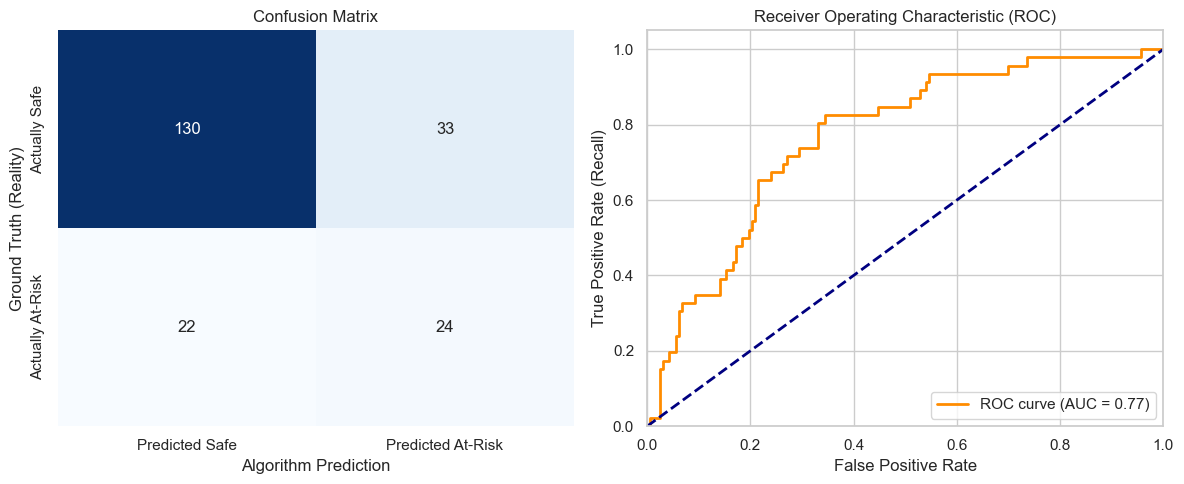

In [13]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

print("CLASSIFICATION REPORT :")
print(classification_report(y_test, y_pred, target_names=['Safe (Pass)', 'At Risk (Fail)']))

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=['Predicted Safe', 'Predicted At-Risk'],
    yticklabels=['Actually Safe', 'Actually At-Risk']
)
plt.title('Confusion Matrix')
plt.xlabel('Algorithm Prediction')
plt.ylabel('Ground Truth (Reality)')

roc_auc = roc_auc_score(y_test, y_pred_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

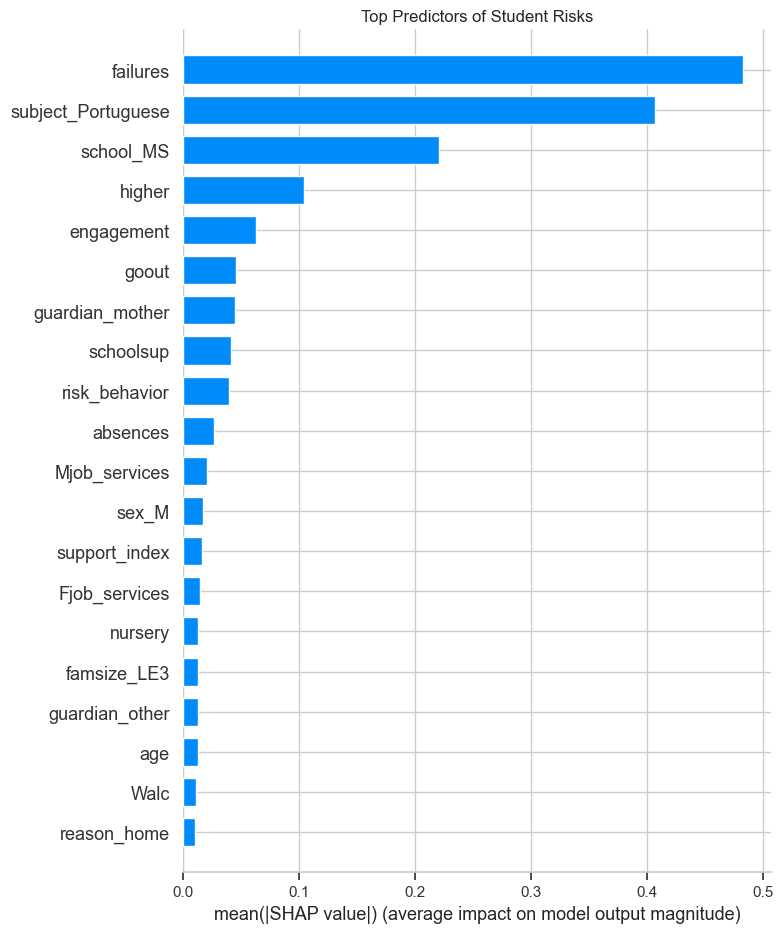

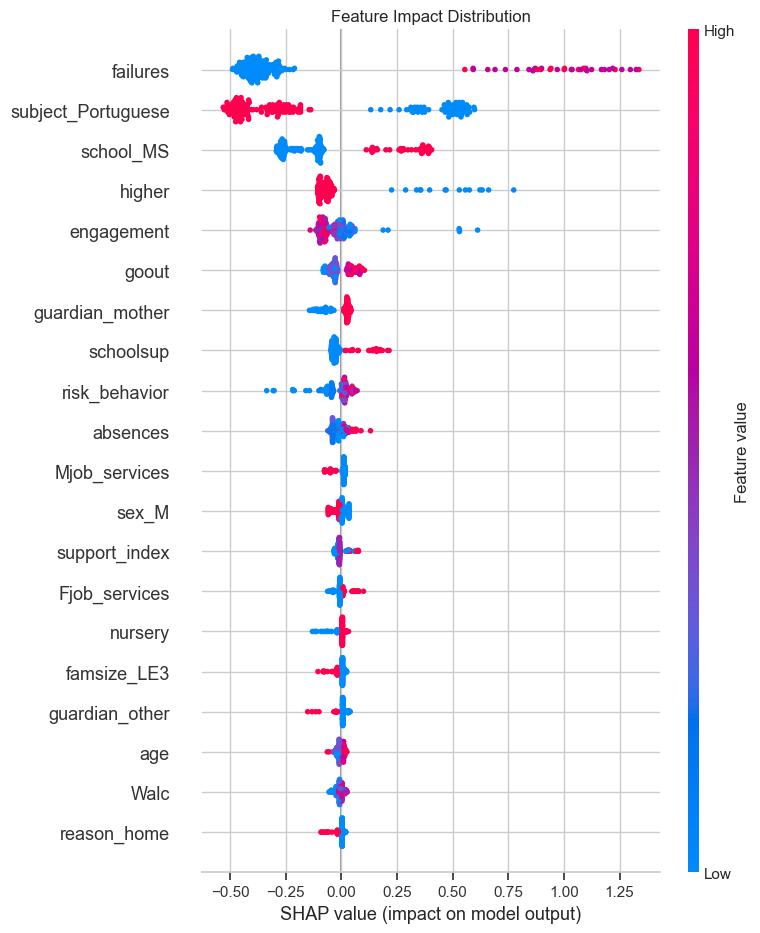


 -- Local Explanation for Student Index: 4 --


Top 10 specific factors driving THIS student's risk:


,Feature,SHAP_Impact,Actual_Raw_Value
42,subject_Portuguese,0.519456,-1.275063
6,schoolsup,0.174243,2.824623
21,support_index,0.075521,1.956254
20,absences,0.030981,1.451482
40,guardian_mother,0.025884,0.653720
22,risk_behavior,0.022737,1.569811
2,Fedu,0.020356,-1.260049
17,Dalc,0.018092,2.859485
31,Mjob_services,0.017414,-0.551985
13,romantic,0.015519,1.318220


In [18]:
import shap

shap.initjs()  # Initialize JS for SHAP plots (Required for Jupyter Notebooks)

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_scaled)

# Global Feature Importance (Bar Plot)
plt.figure(figsize=(10, 6)) 
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar", show=False)
plt.title('Top Predictors of Student Risks')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled, show=False)
plt.title('Feature Impact Distribution')
plt.tight_layout()
plt.show()

# Local Explanation for a Single Student
result_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})
true_positives = result_df[(result_df['Actual'] == 1) & (result_df['Predicted'] == 1)]

if not true_positives.empty:
    student_index = true_positives.index[0]
    print(f"\n -- Local Explanation for Student Index: {student_index} --\n")

    student_shap_values = shap_values[student_index]
    feature_names = X_test_scaled.columns

    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'SHAP_Impact': student_shap_values,
        'Actual_Raw_Value': X_test_scaled.iloc[student_index].values
    })

    feature_importance['Abs_Impact'] = feature_importance['SHAP_Impact'].abs()
    feature_importance = feature_importance.sort_values(by='Abs_Impact', ascending=False)

    top_risk_drivers = feature_importance[feature_importance['SHAP_Impact'] > 0].head(10)

    print("\nTop 10 specific factors driving THIS student's risk:")
    display(top_risk_drivers[['Feature', 'SHAP_Impact', 'Actual_Raw_Value']])

    force_plot = shap.force_plot(
        explainer.expected_value,
        student_shap_values,
        X_test_scaled.iloc[student_index]
    )
    display(force_plot)

else:
    print("No true positives found in the test set for local explanation.")

In [21]:
import json
import os

# the Deterministic Guardrails
INTERVENTION_MAP = {
    'failures': "ACADEMIC: Student has prior failures. ACTION -> Mandate weekly peer-tutoring sessions.",
    'studytime': "HABIT: Low study time detected (<2 hrs/week). ACTION -> Assign mandatory 'Time Management & Study Skills' seminar.",
    'absences': "ATTENDANCE: High absence rate. ACTION -> Trigger automated academic advisor check-in and draft attendance contract.",
    'risk_behavior': "LIFESTYLE: High risk behavior index (Alcohol/Social). ACTION -> Schedule confidential wellness counseling.",
    'support_index': "SUPPORT: Low family/school support. ACTION -> Connect student with on-campus mentorship program.",
    'freetime': "HABIT: Excessive free time negatively impacting grades. ACTION -> Suggest structured extracurriculars or library hours.",
    'goout': "LIFESTYLE: High frequency of going out. ACTION -> Advisor discussion on work-life balance."
}

def generate_intervention_plan(student_id, top_risk_drivers_df):
    """Ingests SHAP risk drivers and outputs a deterministic intervention plan."""
    plan = {
        "student_id": int(student_id),
        "interventions": []
    }
    
    print(f"-- INTERVENTION PLAN FOR STUDENT {int(student_id)}--")
    
    for index, row in top_risk_drivers_df.iterrows():
        feature = row['Feature']
        impact = row['SHAP_Impact']
        raw_value = row['Actual_Raw_Value']
        
        if feature in INTERVENTION_MAP:
            action = INTERVENTION_MAP[feature]
            plan["interventions"].append({
                "feature": feature,
                "action": action
            })
            print(f"🔴 [Trigger: {feature} | SHAP Impact: +{impact:.2f}]")
            print(f"   ↳ {action}\n")
        else:
            # Fallback guardrail for features without specific mappings
            print(f"🟡 [Trigger: {feature} | SHAP Impact: +{impact:.2f}]")
            print(f"   ↳ GENERAL: Discuss impact of '{feature}' during next advising session.\n")
            
    return plan

student_plan = generate_intervention_plan(student_id=student_index, top_risk_drivers_df=top_risk_drivers)

os.makedirs('../data/processed', exist_ok=True)
log_path = f"../data/processed/intervention_log_student_{int(student_index)}.json"

with open(log_path, 'w') as f:
    json.dump(student_plan, f, indent=4)
    
print(f"✅ Intervention plan securely saved to: {log_path}")



-- INTERVENTION PLAN FOR STUDENT 4--
🟡 [Trigger: subject_Portuguese | SHAP Impact: +0.52]
   ↳ GENERAL: Discuss impact of 'subject_Portuguese' during next advising session.

🟡 [Trigger: schoolsup | SHAP Impact: +0.17]
   ↳ GENERAL: Discuss impact of 'schoolsup' during next advising session.

🔴 [Trigger: support_index | SHAP Impact: +0.08]
   ↳ SUPPORT: Low family/school support. ACTION -> Connect student with on-campus mentorship program.

🔴 [Trigger: absences | SHAP Impact: +0.03]
   ↳ ATTENDANCE: High absence rate. ACTION -> Trigger automated academic advisor check-in and draft attendance contract.

🟡 [Trigger: guardian_mother | SHAP Impact: +0.03]
   ↳ GENERAL: Discuss impact of 'guardian_mother' during next advising session.

🔴 [Trigger: risk_behavior | SHAP Impact: +0.02]
   ↳ LIFESTYLE: High risk behavior index (Alcohol/Social). ACTION -> Schedule confidential wellness counseling.

🟡 [Trigger: Fedu | SHAP Impact: +0.02]
   ↳ GENERAL: Discuss impact of 'Fedu' during next advising 

In [22]:
import joblib
import os

def assign_risk_tier(probability):
    """
    Converts ML probability into actionable faculty tiers.
    """
    if probability >= 0.65:
        return "High Risk 🔴"   
    elif probability >= 0.40:
        return "Medium Risk 🟡" 
    else:
        return "Low Risk 🟢"   
    

result_df['Risk_Probability'] = y_pred_proba
result_df['Risk_Tier'] = result_df['Risk_Probability'].apply(assign_risk_tier)

print("RISK TIER DISTRIBUTION (Test Set) : ")
print(result_df['Risk_Tier'].value_counts())

os.makedirs('../models', exist_ok=True)
joblib.dump(best_xgb, '../models/failsafe_xgb_model.pkl')
joblib.dump(scaler, '../models/failsafe_scaler.pkl')
joblib.dump(X_train_scaled.columns.tolist(), '../models/model_features.pkl')

print("\n✅ Model and preprocessing objects saved to '../models/' directory.")



RISK TIER DISTRIBUTION (Test Set) : 
Risk_Tier
Low Risk 🟢       92
Medium Risk 🟡    86
High Risk 🔴      31
Name: count, dtype: int64

✅ Model and preprocessing objects saved to '../models/' directory.
